In [153]:
import random
import torch

## 生成数据集

In [154]:
def synthetic_data(w, b, num_examples):
    X = torch.normal(0, 1, (num_examples, len(w))) # 正态分布随机
    y = torch.matmul(X, w) + b
    y += torch.normal(0,0.01, y.shape) # 正态分布随机
    return X, y

true_w = torch.tensor([2,-3.4])
true_b = 4.2
num_examples = 1000
features, labels = synthetic_data(true_w, true_b, num_examples)

In [155]:
w = torch.randn(2)
b = torch.randn(1)

w.requires_grad_(True)
b.requires_grad_(True)

iters = 10000
batch = 100
rate = 0.001
for i in range(iters):
    lb = 0
    while(lb < num_examples):
        if w.grad is not None: w.grad.zero_()
        if b.grad is not None: b.grad.zero_()
        rb = min(lb+batch, num_examples)
        batch_feature = features[lb:rb,:]
        batch_lables = labels[lb:rb]
        pred_labels = torch.matmul(batch_feature, w) + b
        error = pred_labels - batch_lables
        loss = torch.sum(error ** 2) * 0.5
        loss.backward()
        with torch.no_grad():
            print(f"\r{loss.numpy()}", end="")
            w.sub_(w.grad / batch * rate)
            b.sub_(b.grad / batch * rate)        
        lb += batch
        

0.0044407285749912265

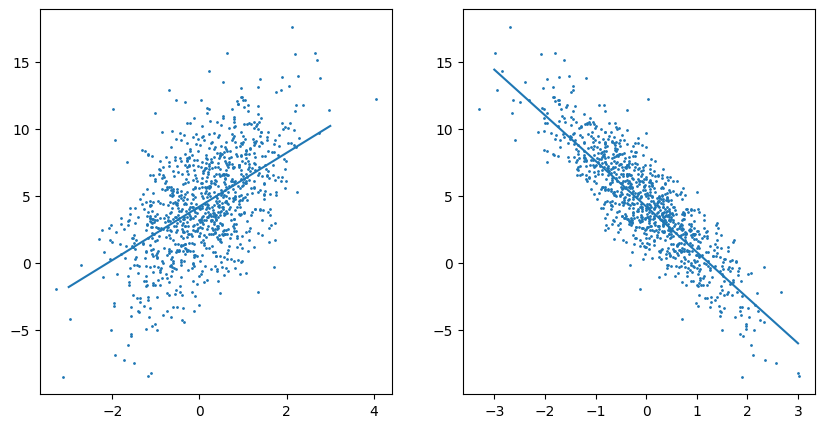

In [156]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(10,5))
sub0 = plt.subplot(121)
sub1 = plt.subplot(122)
sub0.scatter(features[:,0].detach().numpy(), labels.detach().numpy(), s=1)
sub1.scatter(features[:,1].detach().numpy(), labels.detach().numpy(), s=1)

x_plot = np.linspace(-3, 3, 100)
px0 = torch.zeros((100, 2))
px1 = torch.zeros((100, 2))
px0[:, 0] = torch.tensor(x_plot)
px1[:, 1] = torch.tensor(x_plot)
with torch.no_grad():
    py0 = torch.matmul(px0, w) + b
    py1 = torch.matmul(px1, w) + b
sub0.plot(px0[:,0].detach().numpy(), py0.detach().numpy())
sub1.plot(px1[:,1].detach().numpy(), py1.detach().numpy())